# PCA + KMeans and Hierarchical Clustering

Goal: compare unsupervised clustering methods and cluster numbers after PCA dimensionality reduction.

Data assumption: rows are neuron responses/waveforms, columns are time samples at 30 kHz, values are voltage in mV.

## What PCA is and why it matters

Each neuron response has 62 time samples, so each row is a point in 62-dimensional waveform space. PCA finds new axes called principal components that capture the largest sources of waveform variation. For this analysis, PCA helps reduce noise and compress the waveform shape into fewer dimensions before clustering. Clusters in PCA space may reflect waveform families such as different amplitudes, trough timing, spike width, or positive/negative/biphasic waveform structure.

In [1]:
# Imports

import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    adjusted_rand_score
)

plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 20)


In [2]:
# Load cleaned data

filepath = "../data/spike_waveforms_clean.csv"

df = pd.read_csv(
    filepath,
    header=None
)

sampling_rate_hz = 30000
time_ms = np.arange(df.shape[1]) / sampling_rate_hz * 1000

print("Data shape:", df.shape)
print("Rows = neuron responses")
print("Columns = time samples")
print("Duration (ms):", time_ms[-1])

display(df.head())


Data shape: (26862, 62)
Rows = neuron responses
Columns = time samples
Duration (ms): 2.033333333333333


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61
0,28.708333,24.775000,2.341667,0.741667,12.741667,0.708333,-11.291667,-10.891667,2.308333,-0.891667,-6.491667,-11.358333,-27.391667,-23.858333,-15.425000,-13.358333,-2.091667,2.241667,13.008333,35.475000,43.541667,54.775000,69.975000,71.608333,85.575000,86.375000,84.008333,86.408333,75.175000,88.808333,96.408333,3392.475,3289.441667,2714.641667,2339.641667,2006.508333,1767.541667,1590.408333,1441.041667,1287.075000,1162.475000,1005.008333,894.108333,792.775000,704.975000,577.275000,470.608333,381.641667,300.275000,237.808333,176.108333,108.441667,52.741667,19.941667,-11.258333,8.741667,1.508333,-37.425000,-87.458333,-107.858333,-139.025000,-140.758333
1,32.623333,14.990000,5.756667,16.190000,2.623333,4.156667,2.923333,16.623333,11.323333,-10.710000,-16.710000,-4.643333,-9.843333,-23.376667,-15.776667,-8.276667,-9.043333,-12.643333,0.890000,2.923333,22.156667,4.090000,-17.176667,-39.576667,-166.676667,-271.710000,-293.310000,-304.643333,-259.676667,-127.776667,18.956667,150.690,256.756667,347.756667,382.590000,372.523333,329.223333,300.790000,255.523333,206.656667,183.423333,147.856667,85.356667,61.356667,36.190000,24.156667,4.923333,-3.843333,3.756667,-10.643333,-32.376667,-32.776667,-35.976667,-12.776667,-16.310000,-1.110000,0.156667,8.956667,8.090000,4.890000,3.290000,7.356667
2,-32.421667,-33.255000,-18.421667,-8.455000,-12.821667,-4.821667,-12.088333,11.111667,21.945000,24.778333,0.811667,3.645000,24.478333,24.811667,4.378333,-16.388333,-7.555000,1.578333,4.345000,24.345000,52.845000,41.245000,37.678333,-14.021667,-124.155000,-215.221667,-230.988333,-216.521667,-187.521667,-109.821667,0.711667,120.545,226.611667,290.245000,299.845000,296.211667,262.211667,230.578333,213.378333,192.611667,179.711667,158.511667,132.111667,128.111667,108.545000,75.711667,30.145000,28.545000,36.511667,18.078333,16.878333,37.278333,39.345000,35.345000,34.478333,14.478333,8.845000,9.645000,2.111667,-15.121667,-16.788333,0.411667
3,-14.938333,-31.405000,-10.438333,-1.605000,-11.271667,-16.671667,-21.405000,-11.038333,-1.338333,-5.305000,12.328333,10.695000,25.561667,34.328333,25.928333,-3.271667,12.361667,11.195000,-0.838333,-2.871667,-8.938333,11.528333,-11.338333,-59.538333,-131.338333,-183.805000,-259.838333,-323.471667,-297.138333,-203.071667,-51.771667,82.495,171.861667,229.895000,256.728333,260.295000,250.661667,208.595000,188.995000,165.428333,138.561667,100.528333,60.795000,52.028333,44.828333,35.561667,27.161667,5.861667,11.995000,-7.738333,-2.971667,-8.505000,-19.338333,7.561667,24.461667,25.661667,11.261667,9.261667,-5.238333,-28.171667,-32.971667,-29.005000
4,-5.021667,-0.588333,7.811667,15.845000,10.611667,8.211667,0.578333,-1.388333,27.411667,17.378333,9.811667,1.811667,-8.621667,-0.988333,-1.021667,-1.788333,-9.821667,-13.788333,-25.821667,-30.621667,-27.821667,-33.421667,-43.421667,-45.021667,-36.188333,-36.221667,-27.421667,-31.021667,5.845000,47.878333,-298.355000,-366.855,-274.255000,-156.221667,40.245000,171.345000,163.778333,107.178333,62.278333,35.011667,22.245000,15.811667,23.011667,19.045000,13.045000,-16.188333,-22.955000,-28.188333,-30.621667,-17.388333,-6.988333,-19.021667,-17.021667,-32.221667,-38.621667,-28.621667,-26.621667,-10.621667,-20.221667,-11.421667,-16.621667,-24.221667


In [3]:
# Standardize waveforms before PCA

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

print("Scaled data shape:", X_scaled.shape)


Scaled data shape: (26862, 62)


PCs for 90% variance: 6
PCs for 95% variance: 9


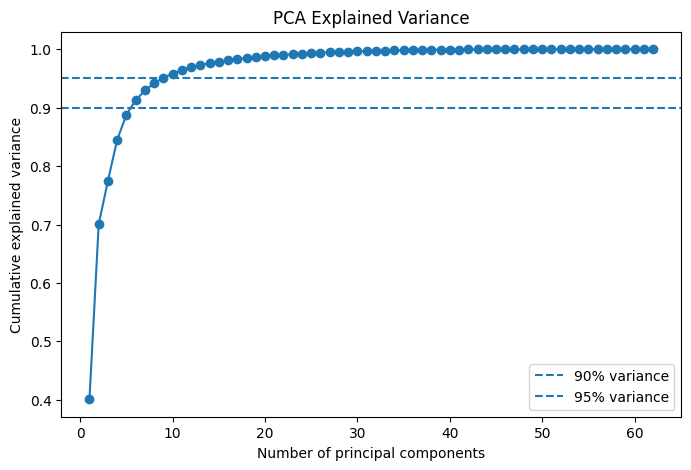

In [4]:
# PCA explained variance

pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_scaled)

explained_variance = pca_full.explained_variance_ratio_
cumulative_explained = np.cumsum(explained_variance)

n_pcs_90 = np.argmax(cumulative_explained >= 0.90) + 1
n_pcs_95 = np.argmax(cumulative_explained >= 0.95) + 1

print("PCs for 90% variance:", n_pcs_90)
print("PCs for 95% variance:", n_pcs_95)

plt.figure(figsize=(8, 5))
plt.plot(
    np.arange(1, len(cumulative_explained) + 1),
    cumulative_explained,
    marker="o"
)
plt.axhline(0.90, linestyle="--", label="90% variance")
plt.axhline(0.95, linestyle="--", label="95% variance")
plt.xlabel("Number of principal components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA Explained Variance")
plt.legend()
plt.show()


In [5]:
# Select PCA representation for clustering

# Use enough PCs to represent waveform structure while reducing noise.
# Cap at 10 PCs to keep clustering stable and interpretable.
n_pcs_for_clustering = min(max(n_pcs_90, 2), 10)

pca = PCA(n_components=n_pcs_for_clustering)
X_pca = pca.fit_transform(X_scaled)

print("PCs used for clustering:", n_pcs_for_clustering)
print("Variance explained by selected PCs:", pca.explained_variance_ratio_.sum())
print("PCA data shape:", X_pca.shape)


PCs used for clustering: 6
Variance explained by selected PCs: 0.9126140774670809
PCA data shape: (26862, 6)


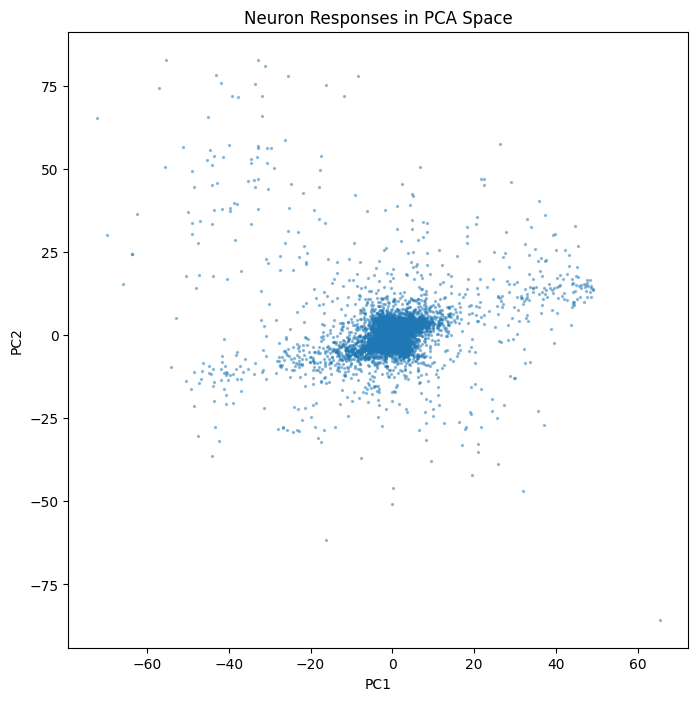

In [6]:
# Visualize all responses in PC1/PC2 space

plt.figure(figsize=(8, 8))
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    s=2,
    alpha=0.4
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Neuron Responses in PCA Space")
plt.show()


In [7]:
# Helper functions

def evaluate_labels(X, labels):
    return {
        "silhouette": silhouette_score(X, labels),
        "calinski_harabasz": calinski_harabasz_score(X, labels),
        "davies_bouldin": davies_bouldin_score(X, labels)
    }


def plot_pca_clusters(X, labels, title):
    plt.figure(figsize=(8, 8))
    scatter = plt.scatter(
        X[:, 0],
        X[:, 1],
        c=labels,
        cmap="tab10",
        s=2,
        alpha=0.5
    )
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title(title)
    plt.colorbar(scatter, label="Cluster")
    plt.show()


def plot_mean_waveforms(df, labels, title):
    labels = np.asarray(labels)
    clusters = np.sort(np.unique(labels))

    plt.figure(figsize=(12, 8))

    for cluster in clusters:
        cluster_waveforms = df.loc[labels == cluster]
        mean_waveform = cluster_waveforms.mean(axis=0)

        plt.plot(
            time_ms,
            mean_waveform,
            linewidth=2,
            label=f"Cluster {cluster}"
        )

    plt.xlabel("Time (ms)")
    plt.ylabel("Voltage (mV)")
    plt.title(title)
    plt.legend()
    plt.show()


def export_clustered_csv(df, labels, label_name, output_path):
    clustered = df.copy()
    clustered.insert(0, label_name, labels)
    clustered.insert(1, "original_row", df.index)
    clustered = clustered.sort_values([label_name, "original_row"])
    clustered.to_csv(output_path, index=False)
    return clustered


## Compare cluster numbers

Silhouette score estimates separation: higher is better. Calinski-Harabasz is also higher-is-better. Davies-Bouldin is lower-is-better. Because the goal is to get the most useful number of clusters with good separation, do not automatically choose `k=2` just because it can score well. Inspect the score curves and waveform shapes. This notebook keeps `selected_k = 7` as the working cluster number while still showing the cluster-number comparison.

In [8]:
# Compare KMeans cluster numbers on all rows

cluster_range = range(2, 15)
kmeans_results = []

for k in cluster_range:
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = km.fit_predict(X_pca) + 1
    metrics = evaluate_labels(X_pca, labels)

    kmeans_results.append({
        "method": "KMeans",
        "k": k,
        "inertia": km.inertia_,
        **metrics
    })

kmeans_eval_df = pd.DataFrame(kmeans_results)
display(kmeans_eval_df)


,method,k,inertia,silhouette,calinski_harabasz,davies_bouldin
0,KMeans,2,1.202131e+06,0.909767,7100.281586,0.615767
1,KMeans,3,9.514928e+05,0.868538,8022.685753,0.657292
2,KMeans,4,7.773401e+05,0.807787,8552.189877,0.737717
3,KMeans,5,6.982101e+05,0.605969,7901.750688,0.968496
4,KMeans,6,6.426343e+05,0.609527,7332.338772,1.024655
5,KMeans,7,6.024893e+05,0.591835,6815.414179,1.078728
6,KMeans,8,5.595552e+05,0.591523,6584.147972,1.027850
7,KMeans,9,5.304731e+05,0.588839,6260.752023,1.082264
8,KMeans,10,5.027729e+05,0.503200,6035.887072,1.131554
9,KMeans,11,4.797371e+05,0.428205,5821.877635,1.152328


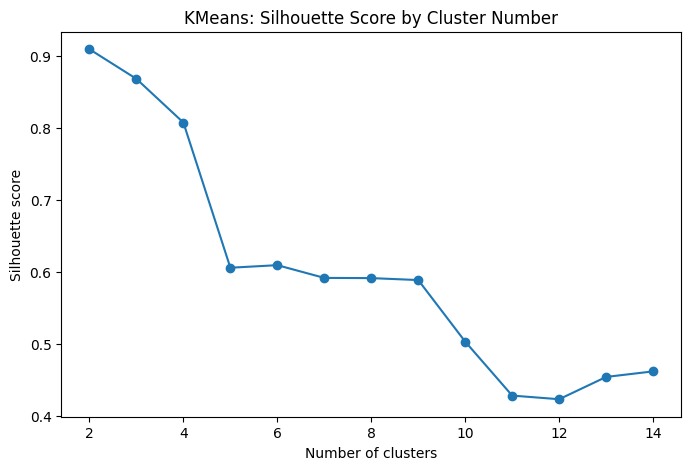

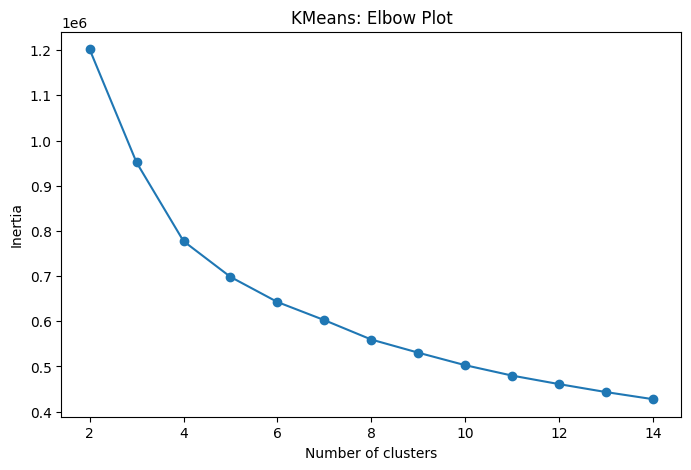

In [9]:
# Plot KMeans evaluation metrics

plt.figure(figsize=(8, 5))
plt.plot(kmeans_eval_df["k"], kmeans_eval_df["silhouette"], marker="o")
plt.xlabel("Number of clusters")
plt.ylabel("Silhouette score")
plt.title("KMeans: Silhouette Score by Cluster Number")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(kmeans_eval_df["k"], kmeans_eval_df["inertia"], marker="o")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.title("KMeans: Elbow Plot")
plt.show()


In [10]:
# Compare hierarchical cluster numbers

# Hierarchical clustering is more expensive than KMeans.
# Use a fixed evaluation sample for cluster-number comparison.
# Final selected-k hierarchical clustering below is run on all rows.

eval_sample_size = min(5000, len(X_pca))
rng = np.random.default_rng(42)
eval_sample_idx = rng.choice(len(X_pca), eval_sample_size, replace=False)
X_eval = X_pca[eval_sample_idx]

hier_results = []

for k in cluster_range:
    hier = AgglomerativeClustering(
        n_clusters=k,
        linkage="ward"
    )

    labels = hier.fit_predict(X_eval) + 1
    metrics = evaluate_labels(X_eval, labels)

    hier_results.append({
        "method": "Hierarchical",
        "k": k,
        "inertia": np.nan,
        **metrics
    })

hier_eval_df = pd.DataFrame(hier_results)
display(hier_eval_df)


,method,k,inertia,silhouette,calinski_harabasz,davies_bouldin
0,Hierarchical,2,NaN,0.876168,1301.381436,0.400251
1,Hierarchical,3,NaN,0.856518,1434.982223,0.835719
2,Hierarchical,4,NaN,0.831054,1443.775663,0.652872
3,Hierarchical,5,NaN,0.573889,1332.748410,0.929156
4,Hierarchical,6,NaN,0.582111,1260.182284,0.917405
5,Hierarchical,7,NaN,0.556201,1204.039876,0.915670
6,Hierarchical,8,NaN,0.551633,1174.516790,0.971702
7,Hierarchical,9,NaN,0.521819,1130.356082,1.052790
8,Hierarchical,10,NaN,0.522421,1079.860236,1.064630
9,Hierarchical,11,NaN,0.522554,1040.670120,1.068157


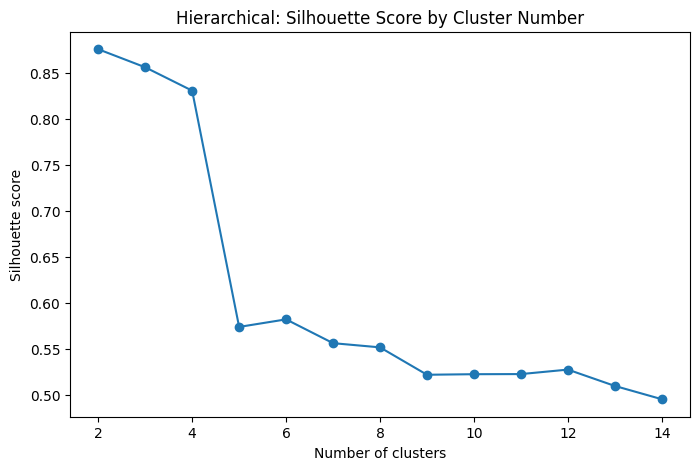

In [11]:
# Plot hierarchical evaluation metrics

plt.figure(figsize=(8, 5))
plt.plot(hier_eval_df["k"], hier_eval_df["silhouette"], marker="o")
plt.xlabel("Number of clusters")
plt.ylabel("Silhouette score")
plt.title("Hierarchical: Silhouette Score by Cluster Number")
plt.show()


In [12]:
# Combined evaluation table

combined_eval_df = pd.concat(
    [kmeans_eval_df, hier_eval_df],
    ignore_index=True
)

display(combined_eval_df.sort_values(["method", "k"]))

os.makedirs("../outputs", exist_ok=True)
combined_eval_df.to_csv(
    "../outputs/clustering_k_comparison_metrics.csv",
    index=False
)


,method,k,inertia,silhouette,calinski_harabasz,davies_bouldin
13,Hierarchical,2,NaN,0.876168,1301.381436,0.400251
14,Hierarchical,3,NaN,0.856518,1434.982223,0.835719
15,Hierarchical,4,NaN,0.831054,1443.775663,0.652872
16,Hierarchical,5,NaN,0.573889,1332.748410,0.929156
17,Hierarchical,6,NaN,0.582111,1260.182284,0.917405
...,...,...,...,...,...,...
8,KMeans,10,502772.864152,0.503200,6035.887072,1.131554
9,KMeans,11,479737.144476,0.428205,5821.877635,1.152328
10,KMeans,12,460895.130590,0.423150,5608.591805,1.172574
11,KMeans,13,443267.388923,0.454136,5434.420301,1.176338


In [13]:
# Select final cluster number

# Use 7 to preserve a higher-resolution grouping while still comparing k above.
selected_k = 7

print("Selected cluster number:", selected_k)


Selected cluster number: 7


## KMeans clustering

In [14]:
# Run KMeans with selected_k on all rows

km = KMeans(
    n_clusters=selected_k,
    random_state=42,
    n_init=10
)

labels_kmeans = km.fit_predict(X_pca) + 1

print(pd.Series(labels_kmeans).value_counts().sort_index())


1     1056
2       73
3     1566
4      193
5      164
6    23711
7       99
Name: count, dtype: int64


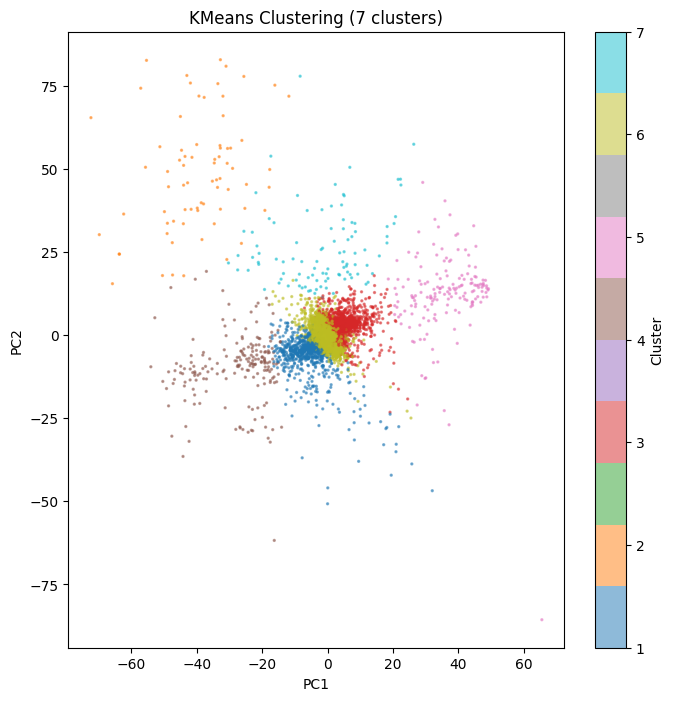

In [15]:
# Plot KMeans clusters in PCA space

plot_pca_clusters(
    X_pca,
    labels_kmeans,
    f"KMeans Clustering ({selected_k} clusters)"
)


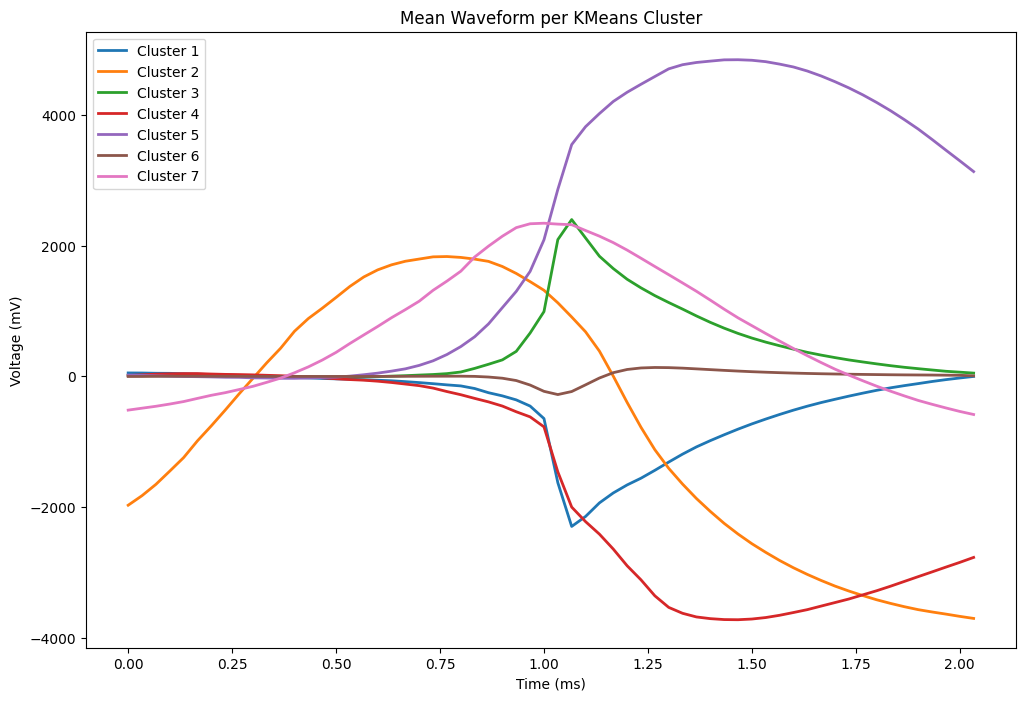

In [16]:
# Plot mean waveform per KMeans cluster

plot_mean_waveforms(
    df,
    labels_kmeans,
    "Mean Waveform per KMeans Cluster"
)


## Hierarchical clustering

In [17]:
# Run hierarchical clustering with selected_k on all rows

hier = AgglomerativeClustering(
    n_clusters=selected_k,
    linkage="ward"
)

labels_hierarchical = hier.fit_predict(X_pca) + 1

print(pd.Series(labels_hierarchical).value_counts().sort_index())


1     1744
2       91
3    21761
4      186
5     2855
6       99
7      126
Name: count, dtype: int64


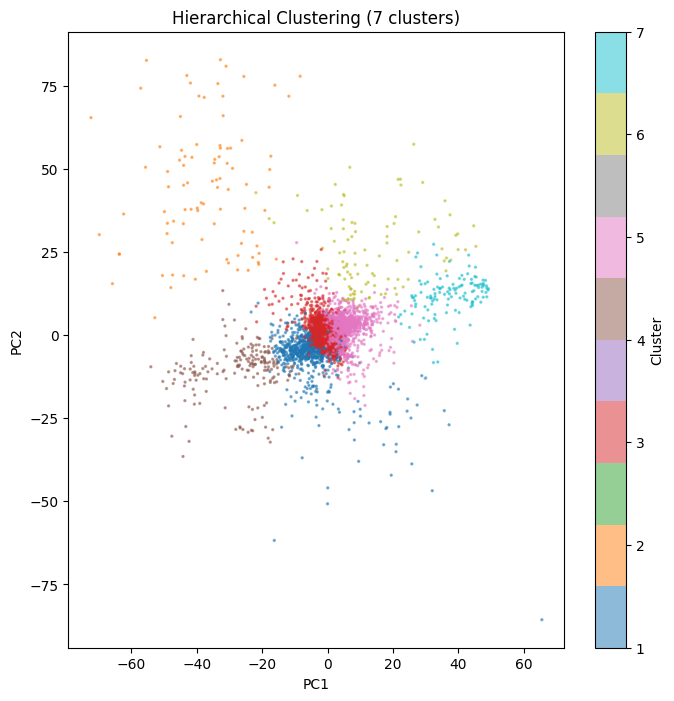

In [18]:
# Plot hierarchical clusters in PCA space

plot_pca_clusters(
    X_pca,
    labels_hierarchical,
    f"Hierarchical Clustering ({selected_k} clusters)"
)


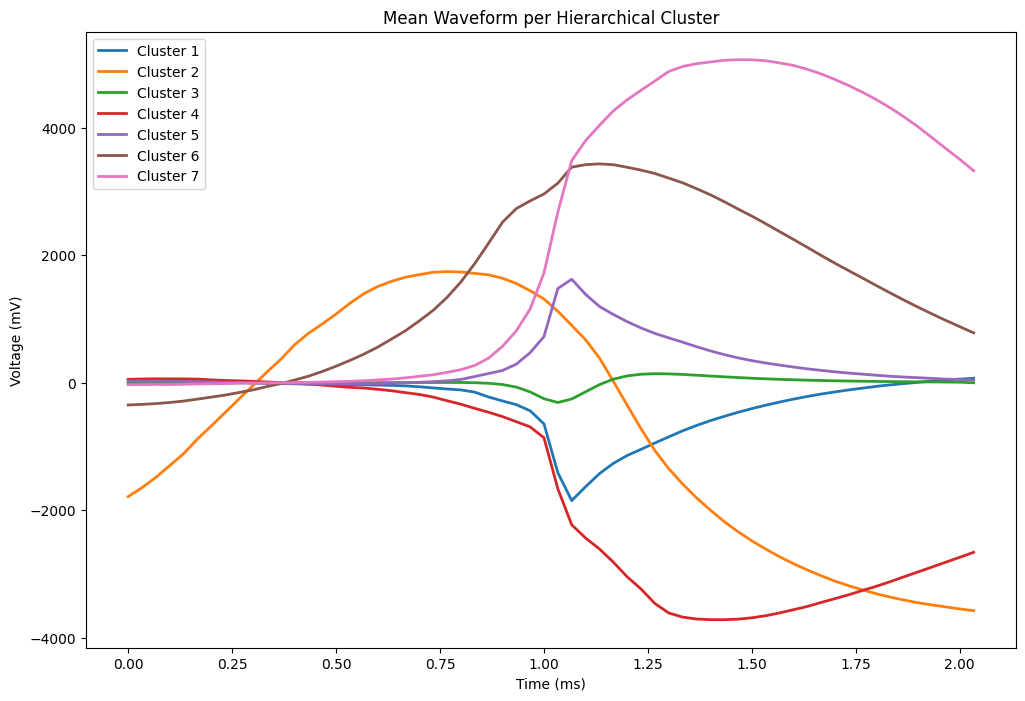

In [19]:
# Plot mean waveform per hierarchical cluster

plot_mean_waveforms(
    df,
    labels_hierarchical,
    "Mean Waveform per Hierarchical Cluster"
)


## Compare KMeans and hierarchical assignments

In [20]:
# Compare cluster assignment agreement

ari = adjusted_rand_score(
    labels_kmeans,
    labels_hierarchical
)

print("Adjusted Rand Index between KMeans and hierarchical:", ari)

comparison_table = pd.crosstab(
    labels_kmeans,
    labels_hierarchical,
    rownames=["KMeans"],
    colnames=["Hierarchical"]
)

display(comparison_table)


Adjusted Rand Index between KMeans and hierarchical: 0.6453579896082509


Hierarchical,1,2,3,4,5,6,7
KMeans,,,,,,,
1,974,0,48,15,19,0,0
2,0,73,0,0,0,0,0
3,5,0,42,0,1499,20,0
4,13,4,5,171,0,0,0
5,5,0,0,0,8,25,126
6,747,0,21640,0,1324,0,0
7,0,14,26,0,5,54,0


In [21]:
# Export cluster assignments and sorted clustered CSVs

cluster_assignments = pd.DataFrame({
    "original_row": df.index,
    "kmeans_cluster": labels_kmeans,
    "hierarchical_cluster": labels_hierarchical
})

cluster_assignments.to_csv(
    "../outputs/cluster_assignments.csv",
    index=False
)

df_kmeans_sorted = export_clustered_csv(
    df,
    labels_kmeans,
    "kmeans_cluster",
    "../outputs/spike_waveforms_kmeans_clustered_sorted.csv"
)

df_hierarchical_sorted = export_clustered_csv(
    df,
    labels_hierarchical,
    "hierarchical_cluster",
    "../outputs/spike_waveforms_hierarchical_clustered_sorted.csv"
)

print("Saved:")
print("../outputs/cluster_assignments.csv")
print("../outputs/spike_waveforms_kmeans_clustered_sorted.csv")
print("../outputs/spike_waveforms_hierarchical_clustered_sorted.csv")


Saved:
../outputs/cluster_assignments.csv
../outputs/spike_waveforms_kmeans_clustered_sorted.csv
../outputs/spike_waveforms_hierarchical_clustered_sorted.csv
